# Leitmotif demo: one clip, end to end

This notebook loads the trained models and runs the whole pipeline on a single audio file:

1. **Audio to graph**: features, one-second segments, temporal and similarity edges
2. **Tags**: the stage 3 cross-attention model predicts context tags from the graph and a caption
3. **Where it happens**: the model's text-to-segment attention shows which moments each word lines up with
4. **Search**: the stage 4 dual encoder finds clips from a text description, and captions for a clip

Run `python -m src.train` for stages 2-4 first; checkpoints are read from `checkpoints/`. To try your own music, point `audio_path` at any audio file (the first 10 seconds are used).

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Audio, display

from src.inference import Leitmotif
from src.plots import BLUE, INK_SECONDARY, style

style()
pd.set_option('display.max_colwidth', 120)
lm = Leitmotif()

## 1. Pick a clip

A MusicCaps test clip the models never saw during training.

In [2]:
test = lm.clips[(lm.clips['split'] == 'test') & lm.clips['has_audio']]
ytid = test.index[42]
clip = lm.clips.loc[ytid]
audio_path = clip['audio_path']
caption = clip['caption']

print(caption)
print('\nLabelled tags:', [t for t in clip['tags'] if t in lm.vocab])
display(Audio(filename=str(audio_path)))

The low quality recording features a live performance that consists of fruity male vocal singing over accordion melody, acoustic rhythm guitar chords and shimmering bells. It sounds emotional and hopeful. The recording is a bit noisy and in mono, as it was probably recorded with a phone.

Labelled tags: ['acoustic guitar', 'emotional', 'live performance', 'low quality', 'mono', 'noisy']


## 2. Audio to graph

In [3]:
model, stats, args = lm.fusion
graph = lm.graph(audio_path, stats)
temporal = int(graph.edge_attr[:, 0].sum())
similar = int(graph.edge_attr[:, 1].sum())
print(f'{graph.num_nodes} segments, {temporal} temporal edges and {similar} similarity edges (directed)')
print(f'node features: {graph.num_node_features} numbers per segment')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


18 segments, 34 temporal edges and 12 similarity edges (directed)
node features: 180 numbers per segment


## 3. Tags

The fusion model was trained on captions with tag words masked, so it has to rely on the audio graph and the remaining context words. Compare its predictions with and without the caption.

In [4]:
with_caption = lm.tags(audio_path, caption, top=8)
audio_only = lm.tags(audio_path, '', top=8)
pd.DataFrame({
    'with caption': [f'{t} ({p:.2f})' for t, p in with_caption.items()],
    'audio + empty caption': [f'{t} ({p:.2f})' for t, p in audio_only.items()],
})

,with caption,audio + empty caption
0,low quality (1.00),slow tempo (0.47)
1,noisy (1.00),relaxing (0.09)
2,mono (0.98),low quality (0.03)
3,emotional (0.97),mellow (0.02)
4,passionate (0.89),amateur recording (0.01)
5,live performance (0.07),emotional (0.01)
6,sad (0.03),medium tempo (0.01)
7,mellow (0.03),live performance (0.01)


## 4. Where in the clip does each word point?

Rows are caption words, columns are one-second segments. Darker cells mean the word attends more to that moment. Special tokens, punctuation, masked words and word pieces are left out.

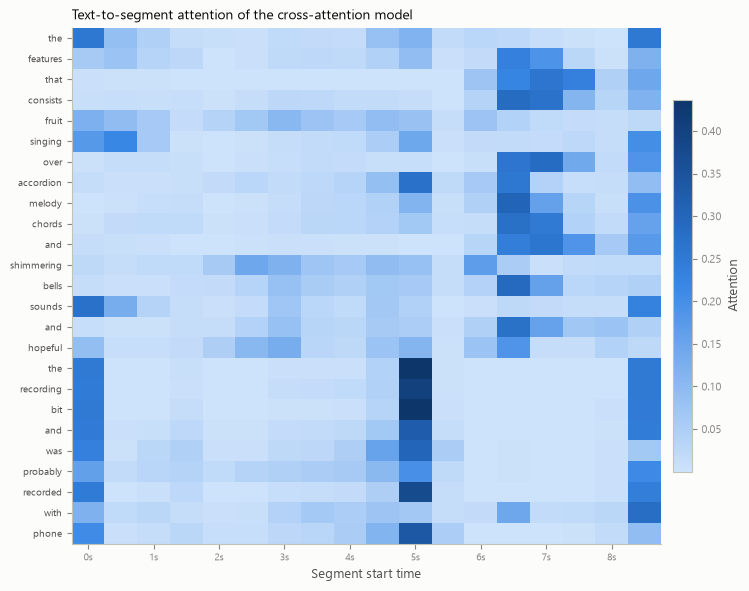

In [5]:
explanation = lm.explain(audio_path, caption)
tokens = explanation['tokens']
keep = [i for i, tok in enumerate(tokens) if tok.isalpha() and tok not in {'[CLS]', '[SEP]', '[MASK]'} and len(tok) > 2]
attention = explanation['attention'][keep]
starts = explanation['segment_seconds'][:, 0]

fig, ax = plt.subplots(figsize=(8, 0.22 * len(keep) + 1.2))
image = ax.imshow(attention, aspect='auto', cmap=BLUE)
ax.set_yticks(range(len(keep)), [tokens[i] for i in keep], fontsize=7, color=INK_SECONDARY)
ax.set_xticks(range(0, len(starts), 2), [f'{s:.0f}s' for s in starts[::2]], fontsize=7)
ax.set_xlabel('Segment start time')
ax.grid(False)
fig.colorbar(image, ax=ax, fraction=0.03, pad=0.02, label='Attention')
ax.set_title('Text-to-segment attention of the cross-attention model', loc='left')
plt.show()

## 5. Search music by description

The dual encoder embeds the query and ranks every MusicCaps clip's audio graph.

In [6]:
for query in ['a calm acoustic guitar melody', 'aggressive distorted electric guitars with fast drums', 'an upbeat electronic dance track']:
    print(f'\nQuery: {query}')
    display(pd.DataFrame(lm.search(query, k=3))[['score', 'caption', 'url']])


Query: a calm acoustic guitar melody


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,score,caption,url
0,0.5150,The low quality recording features an electric guitar melody playing in the left channel only in the first half of t...,https://www.youtube.com/watch?v=1Ccis4FDGwY&t=20s
1,0.5119,The low quality recording features a chill electric guitar melody. It sounds easygoing and relaxing. The recording i...,https://www.youtube.com/watch?v=D-PxXM2I5gY&t=0s
2,0.5009,The low quality recording features an electric guitar melody playing with reverb pedal effect on. The player turns t...,https://www.youtube.com/watch?v=bha-d3HXdMI&t=60s



Query: aggressive distorted electric guitars with fast drums


,score,caption,url
0,0.5271,"This music is instrumental. The tempo is medium fast with a melodic keyboard harmony, punchy drumming, funky bass li...",https://www.youtube.com/watch?v=Pk5NZe-ah4U&t=30s
1,0.5219,An acoustic drum is playing a faster groove along with a bassline and a harmonica playing a chord on the offbeat and...,https://www.youtube.com/watch?v=KdNhYvN4Xoo&t=30s
2,0.5101,This is an energetic rock music piece with a female vocalist singing in the Spanish language. The repeated theme is ...,https://www.youtube.com/watch?v=rs5ecH8Lh3s&t=30s



Query: an upbeat electronic dance track


,score,caption,url
0,0.5085,This reggae song features a male voice singing the main melody. This is accompanied by percussion playing a reggae b...,https://www.youtube.com/watch?v=cmJj7SxQEp8&t=0s
1,0.4923,The low quality recording features a DJ that scratches his vinyl hip hop song. The song consists of punchy snare and...,https://www.youtube.com/watch?v=B32m9Jqqrpo&t=30s
2,0.4872,"The song is an instrumental. The tempo is medium fast with a groovy bass line, massive bass drops, various percussio...",https://www.youtube.com/watch?v=HH3ryAEP308&t=30s


## 6. Describe a clip with its nearest human captions

In [7]:
pd.DataFrame(lm.describe(audio_path, k=3))[['score', 'caption', 'url']]

,score,caption,url
0,0.5131,This song features a choir with male and female voices. Some of the male voices sing the bass part of the vocals. Th...,https://www.youtube.com/watch?v=8PcfPX11Hjg&t=230s
1,0.5022,The Recording features a cover of a pop rock song and it consists of soft acoustic rhythm guitar located in the left...,https://www.youtube.com/watch?v=O9Ag-dE-yfQ&t=0s
2,0.4949,An acoustic guitar and a piano are playing the same chords as single notes with strings underlining the composition....,https://www.youtube.com/watch?v=dsibOgkezN8&t=30s
